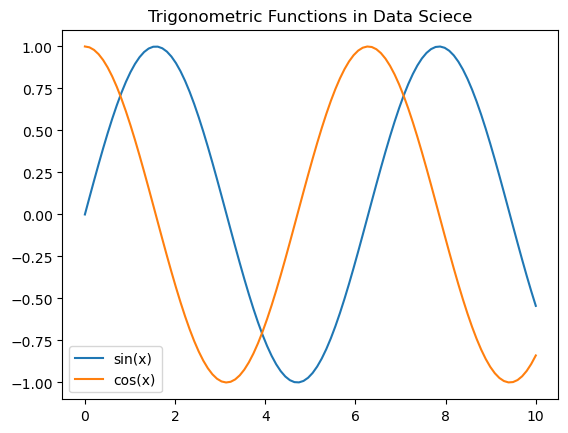

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#Generate time values
x= np.linspace(0,10,100)

#Sine and Cosine wav es
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.plot(x,y_sin, label="sin(x)")
plt.plot(x,y_cos, label="cos(x)")

plt.title("Trigonometric Functions in Data Sciece")
plt.legend()
plt.show()

In [15]:
#Step 1: Impot libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#Step 2: Load dataset
df = pd.read_csv("predict_demand_sample_1008.csv")

print("First 5 rows:\n",df.head())

# Step 3: Features and Target

# Model 1: Without cyclic encoding
X1= df[['hour']]
y= df['demand']

# Model 2: With Cycling encoding
X2= df[['hour_sin','hour_cos']]

#Step 4: Train-Test Split
X1_train, X1_test, y_train, y_test = train_test_split(X1,y,test_size=0.2, random_state=42)
X2_train, X2_test, _,_ =train_test_split(X2,y, test_size=0.2, random_state =42)

#Step 5: Train Models
model1 = LinearRegression()
model1.fit(X1_train, y_train)
model2 = LinearRegression()
model2.fit(X2_train, y_train)

#Step 6: Predictions
y_pred1 = model1.predict(X1_test)
y_pred2 = model2.predict(X2_test)

#Step 7: Evaluate Models
mse1 = mean_squared_error(y_test, y_pred1)
mse2 = mean_squared_error(y_test, y_pred2)
print("\nModel WITHOUT cyclic encoding MSE:", mse1)
print("Model WITH cyclic encoding MSE:",mse2)

#Visualization

plt.figure()
plt.scatter(X1_test, y_test)
plt.scatter(X1_test, y_pred1)
plt.title("Without Cyclic Encoding")
plt.xlabel("hour")
plt.ylabel("demand")
plt.show()

plt.figure()
plt.scatter(df['hour_sin'],df['demand'])
plt.title("With Cyclic Encoding (sin feature")
plt.xlabel("hour_sin")
plt.ylabel("demand")
plt.show()


First 5 rows:
              timestamp  Hour  hour_sin  hour_cos  demand
0  2025-01-01 00:00:00     0  0.000000  1.000000   41.25
1  2025-01-01 01:00:00     1  0.258819  0.965926   38.37
2  2025-01-01 02:00:00     2  0.500000  0.866025   35.94
3  2025-01-01 03:00:00     3  0.707107  0.707107   37.98
4  2025-01-01 04:00:00     4  0.866025  0.500000   37.25


KeyError: "None of [Index(['hour'], dtype='object')] are in the [columns]"